In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
import numpy as np, re, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader


In [2]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/*.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset>
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-30T...
    latitude           float64 ...
    longitude          float64 ...
    station_latitude   (station) float64 ...
    station_longitude  (station) float64 ...
Data variables: (12/14)
    u10                (station, valid_time) float32 ...
    v10                (station, valid_time) float32 ...
    d2m                (station, valid_time) float32 ...
    t2m                (station, valid_time) float32 ...
    msl                (station, valid_time) float32 ...
    sst                (station, valid_time) float32 ...
    ...                 ...
    mwd                (station, valid_time) float32 ...
    mwp                (station, valid_time) float32 ...
    swh                (station, valid_

In [3]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")
ds_sealevel = ds

In [ ]:
import xarray as xr
import numpy as np

# --- series to clean ---
r = ds["residual"].astype("float64")  # (station, valid_time)

# ---- parameters (hourly cadence assumed; adjust if daily etc.) ----
W_BASE    = 24*14   # baseline window for level, ~2 weeks
K_DEV     = 10.0     # how many MADs away from baseline to call it "deviant"
MIN_BLOCK = 24*2    # remove islands shorter than this (2 days)
PAD       = 2       # expand removal by ±PAD samples

# --- robust baseline & dispersion ---
base_med = r.rolling(valid_time=W_BASE, center=True, min_periods=W_BASE//2).median()
mad_lvl  = (np.abs(r - base_med))\
           .rolling(valid_time=W_BASE, center=True, min_periods=W_BASE//2).median()
mad_lvl  = mad_lvl.where(mad_lvl > 1e-12, np.nan)

# --- points that deviate a lot from the local level (candidate islands) ---
deviant = (np.abs(r - base_med) > K_DEV * mad_lvl).fillna(False)  # (station, valid_time) bool

# --- keep ONLY short contiguous runs of "deviant" (i.e., remove short islands) ---
def _short_runs_1d(x, min_run):
    x = np.asarray(x, dtype=bool)
    if x.size == 0:
        return x
    y = np.concatenate(([False], x, [False]))
    dy = np.diff(y.astype(np.int8))
    starts = np.flatnonzero(dy == 1)
    ends   = np.flatnonzero(dy == -1)
    out = np.zeros_like(x, dtype=bool)
    for s, e in zip(starts, ends):
        if (e - s) < min_run:
            out[s:e] = True  # mark only short deviant runs
    return out

short_islands = xr.apply_ufunc(
    _short_runs_1d, deviant,
    input_core_dims=[["valid_time"]],
    output_core_dims=[["valid_time"]],
    vectorize=True, dask="parallelized",
    kwargs={"min_run": MIN_BLOCK},
    output_dtypes=[bool],
)

# optional padding (dilate the mask slightly)
if PAD > 0:
    short_islands = short_islands.rolling(valid_time=2*PAD+1, center=True, min_periods=1).max().astype(bool)

# --- apply (only short islands -> NaN) ---
r_clean = r.where(~short_islands)

# (optional) your “negatives cannot exceed the most positive” rule:
max_pos = r_clean.where(r_clean > 0).max(dim="valid_time", skipna=True)
r_clean = r_clean.where(r_clean >= -max_pos)  # or .where(..., other=0.0) to clamp

# write back
ds["residual_filtered_step"] = r_clean
ds["mask_step_removed"] = short_islands
print("Short step/island points removed:", short_islands.sum().item())

# Correct "NaNs introduced" accounting:
n_before = np.isnan(ds["residual"]).sum().item()
n_after  = np.isnan(ds["residual_filtered_step"]).sum().item()
print("NaNs introduced by step-clean:", n_after - n_before)


In [ ]:
import numpy as np
import xarray as xr

def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    k: float = 10.0,                 # std-dev threshold
    step_thresh: float = 1.5,        # jump threshold (data units)
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),  # ALWAYS keep if within this band
    hard_clip: float = 3.5,          # ALWAYS exclude if |x| > hard_clip
    station_dim: str = "station",
    min_frac_year: float = 0.5,      # keep station if any calendar year has >50% coverage
):
    """
    Returns (filtered_dataset, deviant_mask DataArray).
    Adds `<var>_is_deviant` boolean variable to the returned dataset.
    """
    da = ds[var]
    if dim is None:
        dim = da.dims[0]

    # --- 0) Sort by time to avoid step logic surprises ---
    ds = ds.sortby(dim)
    da = ds[var]

    # --- 1) Z-score filter ---
    mean = da.mean(dim=dim, skipna=True)
    std  = da.std(dim=dim,  skipna=True)
    z = (da - mean) / std
    mask_z = (np.abs(z) > k).fillna(False)

    # --- 2) Hard keep / hard clip ---
    keep_always = (da >= safe_keep_band[0]) & (da <= safe_keep_band[1])
    mask_clip   = (np.abs(da) > hard_clip)  # overrides everything

    # --- 3) Stepwise jump vs last non-deviant from basic masks (z + clip) ---
    basic_bad = (mask_z | mask_clip)
    after_basic = da.where(~basic_bad)
    prev_valid = after_basic.shift({dim: 1}).ffill(dim)
    diff = (da - prev_valid).where(prev_valid.notnull(), 0)
    mask_jump = (np.abs(diff) > step_thresh) & (~keep_always)

    # --- 4) Combine masks with priorities ---
    #   - hard clip wins (always deviant)
    #   - otherwise, if in keep_always band -> not deviant
    #   - otherwise, deviant if z or jump says so
    deviant = mask_clip | ((~keep_always) & (mask_z | mask_jump))

    # Always keep the first point (unless clipped)
    first = {dim: slice(0, 1)}
    deviant = xr.concat(
        [mask_clip.isel(first), deviant.isel({dim: slice(1, None)})],
        dim=dim
    ).astype(bool)

    filtered = da.where(~deviant)

    out = ds.copy()
    out[var] = filtered
    out[f"{var}_is_deviant"] = deviant

    # --- 5) keep station if ANY calendar year has > min_frac_year coverage ---
    if station_dim in out.dims:
        present = out[var].notnull()
        cov_year = present.groupby(f"{dim}.year").mean(dim=dim)  # fraction present per year

        # collapse extra dims if any (keep only station, year)
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        if extra:
            cov_year = cov_year.mean(dim=extra)

        keep_station = (cov_year > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})

    return out, out[f"{var}_is_deviant"]


In [ ]:
import numpy as np
import xarray as xr

def _step_mask_1d(x, zbad, clip, keep, step):
    """
    Causal step detector on a single time series.
    - clip wins (always deviant)
    - keep band wins (never deviant, and updates reference)
    - zbad is deviant (unless in keep band)
    - step test is vs the last *kept* value
    Returns boolean mask of step/z/clip deviants for this 1-D series.
    """
    n = x.size
    m = np.zeros(n, dtype=bool)
    prev = np.nan
    for i in range(n):
        xi = x[i]
        if not np.isfinite(xi):
            # missing: don't update reference
            continue

        if clip[i]:
            m[i] = True
            # don't update prev
            continue

        if keep[i]:
            # always keep and advance reference
            prev = xi
            continue

        if zbad[i]:
            m[i] = True
            # don't update prev
            continue

        # candidate for step test
        if np.isfinite(prev) and (abs(xi - prev) > step):
            m[i] = True
            # don't update prev
        else:
            # kept → advance reference
            prev = xi
    return m

def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    k: float = 5.0,                 # std-dev threshold for z-outliers
    step_thresh: float = 2.0,        # jump threshold (data units)
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),  # ALWAYS keep if within this band
    hard_clip: float = 3.5,          # ALWAYS exclude if |x| >= hard_clip  (inclusive)
    station_dim: str = "station",
    min_frac_year: float = 0.5,      # keep station if any calendar year has >50% coverage
):
    """
    Returns (filtered_dataset, deviant_mask DataArray).
    Adds `<var>_is_deviant` boolean variable to the returned dataset.
    """
    da = ds[var]
    if dim is None:
        dim = da.dims[0]

    # Sort chronologically (cheap and robust)
    ds = ds.sortby(dim)
    da = ds[var]

    # 1) Z-score (computed per-series across `dim`)
    mean = da.mean(dim=dim, skipna=True)
    std  = da.std(dim=dim,  skipna=True)
    z = (da - mean) / std
    mask_z = (np.abs(z) > k).fillna(False)

    # 2) Always-keep band and inclusive hard clip
    keep_always = (da >= safe_keep_band[0]) & (da <= safe_keep_band[1])
    mask_clip   = (da >= hard_clip) | (da <= -hard_clip)  # inclusive at ±3.5

    # 3) Stepwise jump vs last *kept* value (causal)
    # If using dask, process entire time series per chunk to avoid boundary resets
    if hasattr(da.data, "chunks"):
        da = da.chunk({dim: -1})
        mask_z = mask_z.chunk({dim: -1})
        mask_clip = mask_clip.chunk({dim: -1})
        keep_always = keep_always.chunk({dim: -1})

    mask_step = xr.apply_ufunc(
        _step_mask_1d,
        da, mask_z, mask_clip, keep_always,
        input_core_dims=[[dim], [dim], [dim], [dim]],
        output_core_dims=[[dim]],
        vectorize=True,
        dask="parallelized",
        kwargs=dict(step=step_thresh),
        output_dtypes=[bool],
    )

    # Combine: step mask already accounts for z/clip/keep priorities
    deviant = mask_step

    # Always keep the first sample (unless it is hard-clipped)
    first = {dim: slice(0, 1)}
    deviant = xr.concat(
        [mask_clip.isel(first), deviant.isel({dim: slice(1, None)})],
        dim=dim
    ).astype(bool)

    filtered = da.where(~deviant)

    out = ds.copy()
    out[var] = filtered
    out[f"{var}_is_deviant"] = deviant

    # 4) Keep station if ANY calendar year has > min_frac_year coverage
    if station_dim in out.dims:
        present = out[var].notnull()
        cov_year = present.groupby(f"{dim}.year").mean(dim=dim)
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        if extra:
            cov_year = cov_year.mean(dim=extra)
        keep_station = (cov_year > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})

    return out, out[f"{var}_is_deviant"]


In [ ]:
import numpy as np
import xarray as xr
def _step_mask_1d(x, zbad, clip, keep):
    n = x.size
    m = np.zeros(n, dtype=bool)
    prev = np.nan

    for i in range(n):
        xi = x[i]
        if not np.isfinite(xi):
            continue

        # 1) Hard clip still wins
        if clip[i]:
            m[i] = True
            continue

        # 2) STRICT keep for values in [-2, 2], regardless of jump or z
        if abs(xi) <= 2.0 or keep[i]:
            prev = xi
            continue

        # 3) z-outlier (unless already kept)
        if zbad[i]:
            m[i] = True
            continue

        # 4) Step test: disallow |Δ| > 1.5 otherwise
        if np.isfinite(prev):
            if abs(xi - prev) > 1.5:
                m[i] = True
            else:
                prev = xi
        else:
            prev = xi

    return m



def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    k: float = 5.0,                 # std-dev threshold for z-outliers
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),  # ALWAYS keep if within this band
    hard_clip: float = 3.5,         # ALWAYS exclude if |x| >= hard_clip (inclusive)
    station_dim: str = "station",
    min_frac_year: float = 0.5,     # keep station if any calendar year has >50% coverage
    max_steps_per_year: int = 3,    # if > this many step exceedances, delete that year
):
    """
    Returns (filtered_dataset, deviant_mask DataArray).
    Adds `<var>_is_deviant` boolean variable to the returned dataset.

    Changes vs previous:
      - Dynamic step threshold (see _step_mask_1d).
      - Any |x| >= hard_clip is NaN (inclusive).
      - Any calendar year with > `max_steps_per_year` step exceedances is deleted (set to NaN).
    """
    da = ds[var]
    if dim is None:
        dim = da.dims[0]

    # Sort chronologically (cheap and robust)
    ds = ds.sortby(dim)
    da = ds[var]

    # 1) Z-score (computed per-series across `dim`)
    mean = da.mean(dim=dim, skipna=True)
    std  = da.std(dim=dim,  skipna=True)
    z = (da - mean) / std
    mask_z = (np.abs(z) > k).fillna(False)

    # 2) Always-keep band and inclusive hard clip
    keep_always = (da >= safe_keep_band[0]) & (da <= safe_keep_band[1])
    mask_clip   = (da >= hard_clip) | (da <= -hard_clip)  # inclusive at ±hard_clip

    # 3) Causal dynamic step mask (process full series per chunk if dask)
    if hasattr(da.data, "chunks"):
        da = da.chunk({dim: -1})
        mask_z = mask_z.chunk({dim: -1})
        mask_clip = mask_clip.chunk({dim: -1})
        keep_always = keep_always.chunk({dim: -1})

    mask_all = xr.apply_ufunc(
        _step_mask_1d,
        da, mask_z, mask_clip, keep_always,
        input_core_dims=[[dim], [dim], [dim], [dim]],
        output_core_dims=[[dim]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[bool],
    )

    # Combine: step detector already respected z/clip/keep priorities
    deviant = mask_all

    # Always keep the first sample (unless it is hard-clipped)
    first = {dim: slice(0, 1)}
    deviant = xr.concat(
        [mask_clip.isel(first), deviant.isel({dim: slice(1, None)})],
        dim=dim
    ).astype(bool)

    # Filter: NaN all deviants (hard-clip values included)
    filtered = da.where(~deviant)

    out = ds.copy()
    out[var] = filtered
    out[f"{var}_is_deviant"] = deviant

    # --- Identify *step-only* exceedances to count per calendar year ---
    # (Exclude values flagged by z or clip.)
    step_only = mask_all & (~mask_z) & (~mask_clip)

    # Count step exceedances per calendar year (preserving station_dim if present)
    step_counts_year = step_only.groupby(f"{dim}.year").sum(dim=dim, skipna=True)

    # Mark years to delete if step count exceeds threshold
    years_to_delete = (step_counts_year > max_steps_per_year)

    # Delete those years by setting data to NaN (per-station, per-year)
    # This uses groupby alignment on the 'year' coordinate.
    out[var] = out[var].groupby(f"{dim}.year").where(~years_to_delete, other=np.nan)

    # Optionally, you might also want the deviant mask to reflect deleted years:
    deleted_year_mask = xr.ones_like(out[var], dtype=bool).groupby(f"{dim}.year").where(years_to_delete, other=False).fillna(False)
    out[f"{var}_is_deviant"] = out[f"{var}_is_deviant"] | deleted_year_mask

    # 4) Keep station if ANY calendar year has > min_frac_year coverage
    if station_dim in out.dims:
        present = out[var].notnull()
        cov_year = present.groupby(f"{dim}.year").mean(dim=dim)
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        if extra:
            cov_year = cov_year.mean(dim=extra)
        keep_station = (cov_year > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})

    return out, out[f"{var}_is_deviant"]

In [45]:
ds = ds.where(ds["valid_time"].dt.year >= 2000, drop=True)

In [14]:
import numpy as np
import xarray as xr

def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    k: float = 10.0,                 # std-dev threshold
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),  # ALWAYS keep if within this band
    hard_clip: float = 3,          # ALWAYS exclude if |x| > hard_clip
    station_dim: str = "station",
    min_frac_year: float = 0.5,      # keep station if any calendar year has >50% coverage
):
    """
    Returns (filtered_dataset, deviant_mask DataArray).
    Adds `<var>_is_deviant` boolean variable to the returned dataset.

    Step logic (dynamic):
      - Let prev_valid be the last non-deviant (z/clip) value.
      - If prev_valid ∈ [-1, 1] then allowed step = 1.5
        else allowed step = 0.5
      - A point is marked as a jump if |x_t - prev_valid| > allowed step,
        except when x_t is inside the safe_keep_band (always kept).
    """
    da = ds[var]
    if dim is None:
        dim = da.dims[0]

    # --- 0) Sort by time to avoid step logic surprises ---
    ds = ds.sortby(dim)
    da = ds[var].astype("float64")

    # --- 1) Z-score filter ---
    mean = da.mean(dim=dim, skipna=True)
    std  = da.std(dim=dim,  skipna=True)
    z = (da - mean) / std
    mask_z = (np.abs(z) > k).fillna(False)

    # --- 2) Hard keep / hard clip ---
    keep_always = (da >= safe_keep_band[0]) & (da <= safe_keep_band[1])
    mask_clip   = (np.abs(da) > hard_clip)

    # --- 3) Stepwise jump vs last non-deviant from basic masks (z + clip) ---
    basic_bad   = (mask_z | mask_clip)
    after_basic = da.where(~basic_bad)
    prev_valid  = after_basic.shift({dim: 1}).ffill(dim)

    # dynamic threshold based on where the step "takes off" (prev_valid)
    prev_in_small_band = (prev_valid >= -0.5) & (prev_valid <= 0.5)
    allowed_step = xr.where(prev_in_small_band, 1.5, 0.5)

    # difference vs previous valid point
    diff = (da - prev_valid)

    # when prev_valid is NaN (series starts / no history), don't flag as jump
    diff = diff.where(prev_valid.notnull(), 0.0)
    allowed_step = allowed_step.where(prev_valid.notnull(), np.inf)

    # jumps are only considered outside the always-keep band
    mask_jump = (np.abs(diff) > allowed_step) & (~keep_always)

    # --- 4) Combine masks with priorities ---
    #   - hard clip wins (always deviant)
    #   - otherwise, if in keep_always band -> not deviant
    #   - otherwise, deviant if z or jump says so
    deviant = mask_clip | ((~keep_always) & (mask_z | mask_jump))

    # Always keep the first point (unless clipped)
    first = {dim: slice(0, 1)}
    deviant = xr.concat(
        [mask_clip.isel(first), deviant.isel({dim: slice(1, None)})],
        dim=dim
    ).astype(bool)

    filtered = da.where(~deviant)

    out = ds.copy()
    out[var] = filtered
    out[f"{var}_is_deviant"] = deviant

    # --- 5) keep station if ANY calendar year has > min_frac_year coverage ---
    if station_dim in out.dims:
        present = out[var].notnull()
        cov_year = present.groupby(f"{dim}.year").mean(dim=dim)  # fraction present per year
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        if extra:
            cov_year = cov_year.mean(dim=extra)
        keep_station = (cov_year > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})

    return out, out[f"{var}_is_deviant"]


In [25]:
import numpy as np
import xarray as xr
from numba import njit

@njit(cache=True, fastmath=True)
def _mask_1d(values, k, mean, std, safe_lo, safe_hi, hard_clip, p95, p95_margin):
    """
    Boolean mask (True = deviant/NaN) for one 1-D time series.

    Rules:
      - Hard clip:           |x| > hard_clip            -> deviant
      - Safe keep band:      safe_lo <= x <= safe_hi    -> keep (unless hard-clip)
      - Z-score:             |(x-mean)/std| > k         -> deviant  (disabled if std<=0 or NaN)
      - Re-entry gate:       if previous point was NOT kept (outlier/missing),
                             then require x <= p95 + p95_margin; else deviant.
      - Step rule (only if previous was kept):
                             allowed_step = 1.5 if last_kept in [-1, 1], else 0.5
                             deviant if |x - last_kept| > allowed_step (outside safe band)
      - NaNs:                deviant, break baseline
    """
    n = values.shape[0]
    dev = np.zeros(n, dtype=np.bool_)
    last_kept = np.nan
    have_last = False
    prev_was_kept = False

    z_enabled = np.isfinite(std) and std > 0.0
    p95_gate = p95 + p95_margin if np.isfinite(p95) else np.inf  # if p95 bad, don't gate

    for i in range(n):
        x = values[i]

        # Missing -> deviant, break baseline
        if not np.isfinite(x):
            dev[i] = True
            prev_was_kept = False
            continue

        # Hard clip always wins
        if np.abs(x) > hard_clip:
            dev[i] = True
            prev_was_kept = False
            continue

        # Safe band keeps (no z/step/re-entry needed)
        if (x >= safe_lo) and (x <= safe_hi):
            dev[i] = False
            last_kept = x
            have_last = True
            prev_was_kept = True
            continue

        # Z-score check
        if z_enabled:
            z = (x - mean) / std
            if np.abs(z) > k:
                dev[i] = True
                prev_was_kept = False
                continue

        # ---- Re-entry gate (previous was NOT kept) ----
        if not prev_was_kept:
            if x <= p95_gate:
                # accept and re-anchor
                dev[i] = False
                last_kept = x
                have_last = True
                prev_was_kept = True
            else:
                dev[i] = True
                prev_was_kept = False
            continue

        # ---- Step rule (previous WAS kept) ----
        if have_last:
            allowed = 1.5 if (-1.0 <= last_kept <= 1.0) else 0.5
            if np.abs(x - last_kept) > allowed:
                dev[i] = True
                prev_was_kept = False
                continue

        # Keep and update baseline
        dev[i] = False
        last_kept = x
        have_last = True
        prev_was_kept = True

    return dev


def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    k: float = 10.0,                         # z-score threshold
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),
    hard_clip: float = 3.0,
    p95_margin: float = 0.5,                 # re-entry margin above the 95th percentile
    station_dim: str = "station",
    min_frac_year: float = 0.5,
):
    """
    Returns (filtered_dataset, deviant_mask DataArray).
    Adds `<var>_is_deviant` to the returned dataset.

    New bit: if the previous point was *not kept*, the next point must satisfy:
             value <= (series 95th percentile + p95_margin), or it is excluded.
    """
    da = ds[var]
    if dim is None:
        dim = da.dims[0]

    # Sort along time axis
    ds = ds.sortby(dim)
    da = ds[var].astype("float64")

    # Per-series stats along time (no time dim in these)
    mu   = da.mean(dim=dim, skipna=True)
    sig  = da.std(dim=dim,  skipna=True)
    p95  = da.quantile(0.95, dim=dim, skipna=True)

    # Run the kernel across the time axis
    deviant = xr.apply_ufunc(
        _mask_1d,
        da,                          # [dim]
        xr.DataArray(k),             # []
        mu,                          # []
        sig,                         # []
        xr.DataArray(safe_keep_band[0]),  # []
        xr.DataArray(safe_keep_band[1]),  # []
        xr.DataArray(hard_clip),          # []
        p95,                         # []
        xr.DataArray(p95_margin),    # []
        input_core_dims=[[dim], [], [], [], [], [], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[bool],
    )

    out = ds.copy()
    out[f"{var}_is_deviant"] = deviant
    out[var] = da.where(~deviant)

    # Optional: station coverage filter
    if station_dim in out.dims:
        present = out[var].notnull()
        cov_year = present.groupby(f"{dim}.year").mean(dim=dim)
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        if extra:
            cov_year = cov_year.mean(dim=extra)
        keep_station = (cov_year > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})

    return out, out[f"{var}_is_deviant"]


In [108]:
import numpy as np
import xarray as xr
from numba import njit

@njit(cache=True, fastmath=True)
def _mask_1d(values, k_eff, mean, std, safe_lo, safe_hi,
             hard_clip_eff, p95, p95_margin_eff,
             q1, q3, use_quantiles, iqr_mult):
    n = values.shape[0]
    dev = np.zeros(n, dtype=np.bool_)
    last_kept = np.nan; have_last=False; prev_was_kept=False
    z_enabled = np.isfinite(std) and std > 0.0
    p95_gate = p95 + p95_margin_eff if np.isfinite(p95) else np.inf
    iqr = q3 - q1
    lo_iqr = q1 - iqr_mult * iqr
    hi_iqr = q3 + iqr_mult * iqr

    for i in range(n):
        x = values[i]
        if not np.isfinite(x): dev[i]=True; prev_was_kept=False; continue
        if np.abs(x) > hard_clip_eff: dev[i]=True; prev_was_kept=False; continue
        if (x >= safe_lo) and (x <= safe_hi): dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True; continue
        if use_quantiles and ((x < lo_iqr) or (x > hi_iqr)): dev[i]=True; prev_was_kept=False; continue
        if z_enabled:
            z = (x - mean) / std
            if np.abs(z) > k_eff: dev[i]=True; prev_was_kept=False; continue
        if not prev_was_kept:
            if x <= p95_gate: dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
            else: dev[i]=True; prev_was_kept=False
            continue
        if have_last:
            allowed = 1.5 if (-1.0 <= last_kept <= 1.0) else 0.5
            if np.abs(x - last_kept) > allowed: dev[i]=True; prev_was_kept=False; continue
        dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
    return dev

def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    base_k: float = 5.0,
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),
    hard_clip: float = 3.0,
    p95_margin: float = 0.5,
    station_dim: str = "station",
    min_frac_year: float = 0.5,
    kurt_hard: float = 1.0,  
):
    da = ds[var]; dim = da.dims[0] if dim is None else dim
    ds = ds.sortby(dim); da = ds[var].astype("float64")

    mu   = da.mean(dim=dim, skipna=True)
    sig  = da.std(dim=dim,  skipna=True)
    p95  = da.quantile(0.95, dim=dim, skipna=True)
    qs   = da.quantile([0.25, 0.75], dim=dim, skipna=True)
    q1, q3 = qs.sel(quantile=0.25), qs.sel(quantile=0.75)

    # Tail heaviness: excess kurtosis
    m2 = da.var(dim=dim, skipna=True)
    m4 = ((da - mu) ** 4).mean(dim=dim, skipna=True)
    ex_kurt = xr.where(m2 > 0, m4 / (m2 ** 2) - 3.0, 0.0)

    heavy = ex_kurt > kurt_hard

    # --- Aggressive regime if heavy tail ---
    k_eff            = xr.where(heavy, base_k / 2.5, base_k)     # ≈ 2.0σ when heavy
    iqr_mult         = xr.where(heavy, 1.0, 1.5)                 # tighter IQR fence
    hard_clip_eff    = xr.where(heavy, 2.0, hard_clip)           # clip sooner
    p95_margin_eff   = xr.where(heavy, 0.1, p95_margin)          # tougher re-entry
    use_quantiles    = heavy                                     

    deviant = xr.apply_ufunc(
        _mask_1d,
        da, k_eff, mu, sig,
        xr.DataArray(safe_keep_band[0]), xr.DataArray(safe_keep_band[1]),
        hard_clip_eff, p95, p95_margin_eff,
        q1, q3, use_quantiles, iqr_mult,
        input_core_dims=[[dim], [], [], [], [], [], [], [], [], [], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    out = ds.copy()
    out[f"{var}_is_deviant"] = deviant
    out[var] = da.where(~deviant)

    if station_dim in out.dims:
        present = out[var].notnull()
        cov_year = present.groupby(f"{dim}.year").mean(dim=dim)
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        if extra: cov_year = cov_year.mean(dim=extra)
        keep_station = (cov_year > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})
    return out, out[f"{var}_is_deviant"]



In [110]:
import numpy as np
import xarray as xr
from numba import njit

@njit(cache=True, fastmath=True)
def _mask_1d(values, k_eff, mean, std, safe_lo, safe_hi,
             hard_clip_eff, p95, p95_margin_eff,
             q1, q3, use_quantiles, iqr_mult):
    n = values.shape[0]
    dev = np.zeros(n, dtype=np.bool_)
    last_kept = np.nan; have_last=False; prev_was_kept=False
    z_enabled = np.isfinite(std) and std > 0.0
    p95_gate = p95 + p95_margin_eff if np.isfinite(p95) else np.inf
    iqr = q3 - q1
    lo_iqr = q1 - iqr_mult * iqr
    hi_iqr = q3 + iqr_mult * iqr
    for i in range(n):
        x = values[i]
        if not np.isfinite(x): dev[i]=True; prev_was_kept=False; continue
        if np.abs(x) > hard_clip_eff: dev[i]=True; prev_was_kept=False; continue
        if (x >= safe_lo) and (x <= safe_hi): dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True; continue
        if use_quantiles and ((x < lo_iqr) or (x > hi_iqr)): dev[i]=True; prev_was_kept=False; continue
        if z_enabled:
            z = (x - mean) / std
            if np.abs(z) > k_eff: dev[i]=True; prev_was_kept=False; continue
        if not prev_was_kept:
            if x <= p95_gate: dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
            else: dev[i]=True; prev_was_kept=False
            continue
        if have_last:
            allowed = 1.5 if (-1.0 <= last_kept <= 1.0) else 0.5
            if np.abs(x - last_kept) > allowed: dev[i]=True; prev_was_kept=False; continue
        dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
    return dev

# FAST block-drift mask: EW-quantile (median) + run-length
@njit(cache=True, fastmath=True)
def _block_mask_1d(values, med_thresh, min_run, alpha):
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    m = 0.0                        # EW median estimate (starts near 0 for residuals)
    run = 0                        # consecutive samples with |m| > threshold
    for i in range(n):
        x = values[i]
        if np.isfinite(x):
            # Robbins–Monro quantile update (tau=0.5 -> median)
            m += alpha * (0.5 - (1.0 if x < m else 0.0))
            if np.abs(m) > med_thresh:
                run += 1
                if run == min_run:
                    # backfill the initial block once threshold run is reached
                    start = i - min_run + 1
                    for j in range(start, i + 1):
                        block[j] = True
                elif run > min_run:
                    block[i] = True
            else:
                run = 0
        else:
            run = 0  # NaN breaks the block
    return block

def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    base_k: float = 5.0,
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),
    hard_clip: float = 3.0,
    p95_margin: float = 0.5,
    station_dim: str = "station",
    min_frac_year: float = 0.5,
    kurt_hard: float = 1.0,
    # block-drift knobs (fast)
    med_thresh: float = 0.5,
    block_window: int = 91,   # sets EW step via alpha ~ 2/(W+1)
    min_run: int = 60,
):
    da = ds[var]; dim = da.dims[0] if dim is None else dim
    ds = ds.sortby(dim); da = ds[var].astype("float64")

    mu   = da.mean(dim=dim, skipna=True)
    sig  = da.std(dim=dim,  skipna=True)
    p95  = da.quantile(0.95, dim=dim, skipna=True)
    qs   = da.quantile([0.25, 0.75], dim=dim, skipna=True)
    q1, q3 = qs.sel(quantile=0.25), qs.sel(quantile=0.75)

    # tail heaviness
    m2 = da.var(dim=dim, skipna=True)
    m4 = ((da - mu) ** 4).mean(dim=dim, skipna=True)
    ex_kurt = xr.where(m2 > 0, m4 / (m2 ** 2) - 3.0, 0.0)
    heavy = ex_kurt > kurt_hard

    # aggressive mode when heavy
    k_eff          = xr.where(heavy, base_k / 2.5, base_k)
    iqr_mult       = xr.where(heavy, 1.0, 1.5)
    hard_clip_eff  = xr.where(heavy, 2.0, hard_clip)
    p95_margin_eff = xr.where(heavy, 0.1, p95_margin)
    use_quantiles  = heavy

    dev_point = xr.apply_ufunc(
        _mask_1d,
        da, k_eff, mu, sig,
        xr.DataArray(safe_keep_band[0]), xr.DataArray(safe_keep_band[1]),
        hard_clip_eff, p95, p95_margin_eff,
        q1, q3, use_quantiles, iqr_mult,
        input_core_dims=[[dim], [], [], [], [], [], [], [], [], [], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    # **FAST block drift** (no rolling median)
    alpha = 2.0 / (block_window + 1.0)  # EW step ~ window length
    dev_block = xr.apply_ufunc(
        _block_mask_1d,
        da,
        xr.DataArray(med_thresh),
        xr.DataArray(np.int64(min_run)),
        xr.DataArray(alpha),
        input_core_dims=[[dim], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    deviant = dev_point | dev_block

    out = ds.copy()
    out[f"{var}_is_deviant"] = deviant
    out[var] = da.where(~deviant)

    if station_dim in out.dims:
        present = out[var].notnull()
        cov_year = present.groupby(f"{dim}.year").mean(dim=dim)
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        if extra: cov_year = cov_year.mean(dim=extra)
        keep_station = (cov_year > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})
    return out, out[f"{var}_is_deviant"]


In [118]:
from numba import njit

@njit(cache=True, fastmath=True)
def _yrmean_block_mask_1d(values, yr_mean_vals, good_year_vals,
                          mean_abs_thresh, band, min_run):
    """
    Flag contiguous runs that stay near the (shifted) yearly mean, but only
    in years where |yearly mean| > mean_abs_thresh and coverage was 'good'.
    """
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    run = 0
    start = 0
    for i in range(n):
        x = values[i]
        if not np.isfinite(x):
            run = 0
            continue

        if not good_year_vals[i]:
            # year not eligible: reset run
            run = 0
            continue

        ymean = yr_mean_vals[i]
        if not np.isfinite(ymean) or (np.abs(ymean) <= mean_abs_thresh):
            # yearly mean not "shifted" enough
            run = 0
            continue

        # Are we "near" the shifted yearly mean?
        if np.abs(x - ymean) <= band:
            if run == 0:
                start = i
            run += 1
            if run == min_run:
                for j in range(start, i + 1):
                    block[j] = True
            elif run > min_run:
                block[i] = True
        else:
            run = 0
    return block
def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    base_k: float = 5.0,
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),
    hard_clip: float = 3.0,
    p95_margin: float = 0.5,
    station_dim: str = "station",
    min_frac_year: float = 0.5,
    kurt_hard: float = 1.0,
    # mean-shift block knobs
    year_mean_abs_thresh: float = 1.0,   # consider a year "shifted" if |year mean| > 1 m
    block_band: float = 0.5,             # samples within ±band of the yearly mean count toward a block
    min_run: int = 60,                   # consecutive samples near the mean to declare a block
):
    da = ds[var]; dim = da.dims[0] if dim is None else dim
    ds = ds.sortby(dim); da = ds[var].astype("float64")

    # --- robust stats (unchanged)
    mu   = da.mean(dim=dim, skipna=True)
    sig  = da.std(dim=dim,  skipna=True)
    p95  = da.quantile(0.95, dim=dim, skipna=True)
    qs   = da.quantile([0.25, 0.75], dim=dim, skipna=True)
    q1, q3 = qs.sel(quantile=0.25), qs.sel(quantile=0.75)

    m2 = da.var(dim=dim, skipna=True)
    m4 = ((da - mu) ** 4).mean(dim=dim, skipna=True)
    ex_kurt = xr.where(m2 > 0, m4 / (m2 ** 2) - 3.0, 0.0)
    heavy = ex_kurt > kurt_hard

    k_eff          = xr.where(heavy, base_k / 2.5, base_k)
    iqr_mult       = xr.where(heavy, 1.0, 1.5)
    hard_clip_eff  = xr.where(heavy, 2.0, hard_clip)
    p95_margin_eff = xr.where(heavy, 0.1, p95_margin)
    use_quantiles  = heavy

    dev_point = xr.apply_ufunc(
        _mask_1d,
        da, k_eff, mu, sig,
        xr.DataArray(safe_keep_band[0]), xr.DataArray(safe_keep_band[1]),
        hard_clip_eff, p95, p95_margin_eff,
        q1, q3, use_quantiles, iqr_mult,
        input_core_dims=[[dim], [], [], [], [], [], [], [], [], [], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    # --- yearly mean and coverage (unchanged)
    present = da.notnull()
    cov_year = present.groupby(f"{dim}.year").mean(dim=dim)         # fraction present per year
    yr_mean  = da.groupby(f"{dim}.year").mean(dim=dim, skipna=True)  # mean per year
    good_year = cov_year > min_frac_year

    # --- NEW: broadcast per-year values back to each timestamp by selecting with a per-sample 'year' indexer
    # Ensure time axis is datetime64
    if not np.issubdtype(ds[dim].dtype, np.datetime64):
        # If your coord isn't datetime64, convert it here (one-time)
        ds = ds.assign_coords({dim: xr.converters.to_datetime64(ds[dim])})
        da = ds[var].astype("float64")

    year_indexer = xr.DataArray(
        ds[dim].dt.year,         # vector of years for every sample along `dim`
        dims=dim,
        coords={dim: ds[dim]}
    )

    # These now have the SAME dims as `da` (broadcasted back from 'year')
    yr_mean_full   = yr_mean.sel(year=year_indexer)
    good_year_full = good_year.sel(year=year_indexer)

    # --- block detector: runs near the shifted yearly mean
    dev_block = xr.apply_ufunc(
        _yrmean_block_mask_1d,
        da,
        yr_mean_full,
        good_year_full,
        xr.DataArray(year_mean_abs_thresh),
        xr.DataArray(block_band),
        xr.DataArray(np.int64(min_run)),
        input_core_dims=[[dim], [dim], [dim], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    deviant = dev_point | dev_block

    out = ds.copy()
    out[f"{var}_is_deviant"] = deviant
    out[var] = da.where(~deviant)

    if station_dim in out.dims:
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        cov_check = cov_year if not extra else cov_year.mean(dim=extra)
        keep_station = (cov_check > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})

    return out, out[f"{var}_is_deviant"]


In [119]:
# ds: xr.Dataset with a variable named "residual" along dimension "time"
ds_filtered, dev_mask = filter_residual(ds, var="residual", dim="valid_time")

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


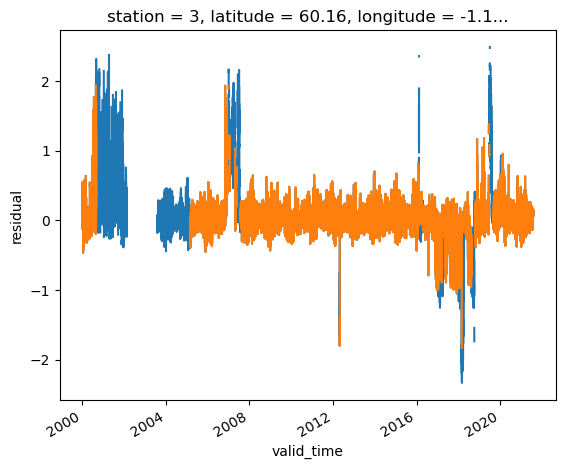

In [112]:
ds.isel(station=2).residual.plot()
ds_filtered.isel(station=2).residual.plot()

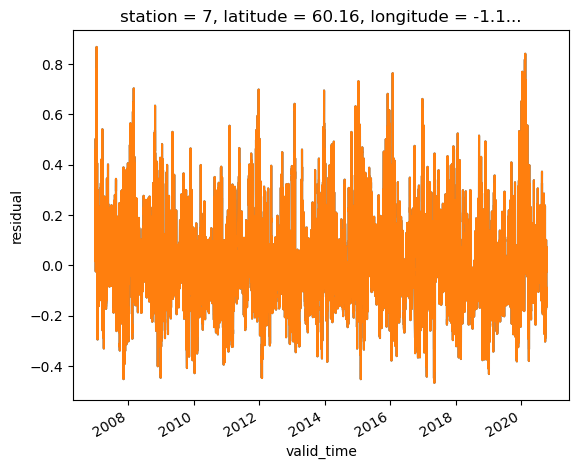

In [120]:
x=7
ds.sel(station=x).residual.plot()
ds_filtered.sel(station=x).residual.plot()

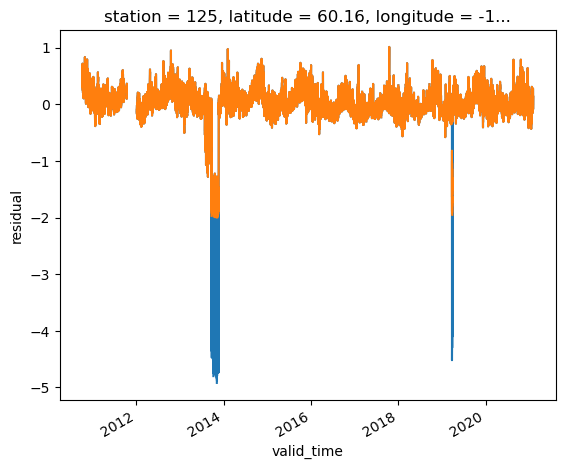

In [121]:
ds.sel(station=125).residual.plot()
ds_filtered.sel(station=125).residual.plot()

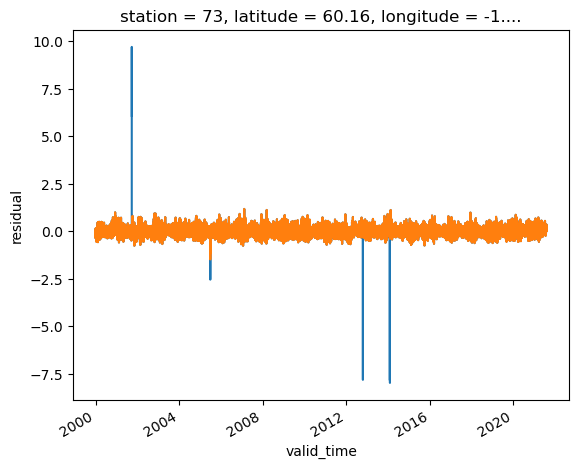

In [122]:
ds.sel(station=73).residual.plot()
ds_filtered.sel(station=73).residual.plot()

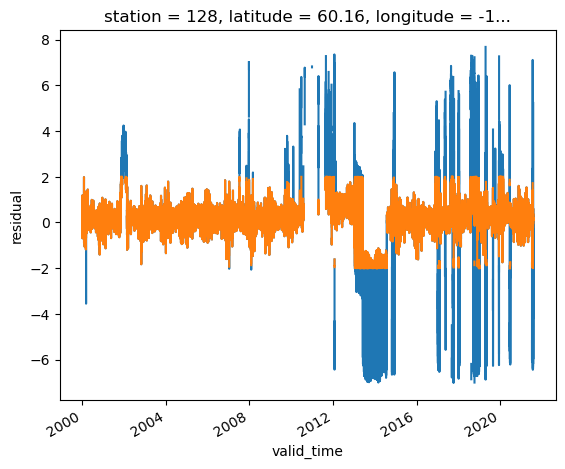

In [123]:
ds.sel(station=128).residual.plot()
ds_filtered.sel(station=128).residual.plot()

In [ ]:
ds.isel(station=135).residual.plot()
ds_filtered.isel(station=135).residual.plot()

In [ ]:
ds.isel(station=138).residual.plot()
ds_filtered.isel(station=138).residual.plot()

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# assume your dataset is ds
# pick one station to demonstrate
station_id = 125  # example
residual = ds.residual.sel(station=station_id).to_pandas()

In [ ]:
# Z-score threshold
z_thresh = 3

z_scores = (residual - residual.mean()) / residual.std()
residual_z_filtered = residual.where(np.abs(z_scores) < z_thresh)

plt.figure(figsize=(12,4))
plt.plot(residual, label="Original Residual", alpha=0.6)
plt.plot(residual_z_filtered, label="Z-score Filtered", alpha=0.8)
plt.legend(); plt.title("Z-Score Filtering")
plt.show()

In [ ]:
ds = ds_sealevel

In [ ]:
import xarray as xr
import numpy as np

# keep original untouched
ds["original"] = ds["residual"].astype("float64")

# --- Compute station-wise mean and std ---
mu  = ds["original"].mean(dim="valid_time", skipna=True)
sig = ds["original"].std(dim="valid_time", skipna=True)

# --- Build mask using Z-score ---
z_thresh = 5
z_scores = (ds["original"] - mu) / sig
mask = np.abs(z_scores) < z_thresh   # True = keep, False = set to NaN

# --- Apply Z-score filter ---
resid_filt = ds["original"].where(mask)

# --- Clause: negatives cannot exceed positives in magnitude ---
# compute max positive per station
max_pos = resid_filt.where(resid_filt > 0).max(dim="valid_time", skipna=True)

# build a mask: keep only if residual >= -max_pos
mask_balance = resid_filt >= (-max_pos)

# apply mask (bad negatives -> NaN)
resid_filt2 = resid_filt.where(mask_balance)

# assign back
ds["residual_filtered"] = resid_filt2

# --- Verify ---
print("Original count:", np.isfinite(ds["original"]).sum().item())
print("Filtered count:", np.isfinite(ds["residual_filtered"]).sum().item())
print("NaNs introduced:", np.isnan(ds["residual_filtered"]).sum().item())


In [ ]:
ds.sel(station=125).original.plot()

In [ ]:
ds.sel(station=125).residual_filtered.plot()

In [ ]:
ds.sel(station=3).original.plot()

In [ ]:
ds.sel(station=4).original.plot()

In [ ]:
ds.sel(station=4).residual_filtered.plot()

In [ ]:
ds.sel(station=3).residual_filtered.plot()


In [ ]:
# rolling mean ± k * rolling std
window = 48   # 2 days if hourly
k = 3

rolling_mean = residual.rolling(window=window, min_periods=1).mean()
rolling_std = residual.rolling(window=window, min_periods=1).std()

mask = (residual > rolling_mean - k*rolling_std) & (residual < rolling_mean + k*rolling_std)
residual_roll_filtered = residual.where(mask)


# try rolling mean

In [ ]:
# rolling mean ± k * rolling std
window = 48  # 2 days if hourly
k = 3

rolling_mean = residual.rolling(window=window, min_periods=1).mean()
rolling_std = residual.rolling(window=window, min_periods=1).std()

mask = (residual > rolling_mean - k*rolling_std) & (residual < rolling_mean + k*rolling_std)
residual_roll_filtered = residual.where(mask)
plt.figure(figsize=(12,4))
plt.plot(residual, label="Original Residual", alpha=0.6)
plt.plot(residual_roll_filtered, label="Rolling Window Filtered", alpha=0.8)
plt.legend(); plt.title("Rolling Window Filtering")
plt.show()

In [ ]:
z-score filter the dataset